# Personal Loan Campaign Project - Decision Tree

---
## Section 1: Problem Statement

### Context

AllLife Bank is expanding its customer base in the US, with most customers holding deposits of various sizes. Only a small portion currently take loans, and the bank wants to grow this segment quickly to increase loan revenue. 

The goal is to convert more existing depositors into personal‑loan customers while keeping them as loyal account holders.
A campaign run last year achieved a strong conversion rate of over 9%, motivating the retail marketing team to design more targeted and effective campaigns.

As the data scientist at AllLife Bank, my task is to build a model that helps the marketing team identify which customers are most likely to take a personal loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

---
## Section 2: Importing necessary libraries

In [1]:
# Install profiling package (needed if not already installed)
#%pip install ydata-profiling

# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#  EDA
import sweetviz as sv

# Library to split the dataset & create preprocessing pipelines
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Libraries for machine learning algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn import tree
import re

# Library for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Libraries to evaluate the model
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, accuracy_score, precision_score, recall_score ,f1_score
)

# To ignore warnings
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

---
## Section 3: Loading the dataset

In [2]:
df = pd.read_csv("Loan_Modelling.csv")
df.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


---
## Section 4: Data Overview

In [3]:
Loan = df.copy()
Loan.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [4]:

print(f"shape of the dataset: {Loan.shape}")
print(f"Number of rows: {Loan.shape[0]}, Number of columns: {Loan.shape[1]}")

print("\n------------------------------\n")

print("Data types of each column:")
print(Loan.dtypes)

print("\n------------------------------\n")

# Statistical summary of the dataset
print("Summary statistics:")
Loan.describe()


shape of the dataset: (5000, 14)
Number of rows: 5000, Number of columns: 14

------------------------------

Data types of each column:
ID                      int64
Age                     int64
Experience              int64
Income                  int64
ZIPCode                 int64
Family                  int64
CCAvg                 float64
Education               int64
Mortgage                int64
Personal_Loan           int64
Securities_Account      int64
CD_Account              int64
Online                  int64
CreditCard              int64
dtype: object

------------------------------

Summary statistics:


,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93169.257000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,1759.455086,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,90005.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


---

## Section 5: Exploratory Data Analysis (EDA)

In [5]:
# Standardise column names by stripping whitespace from the headers  

Loan.columns = [c.strip() for c in Loan.columns]
Loan.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIPCode', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account',
       'CD_Account', 'Online', 'CreditCard'],
      dtype='str')

### EDA Profile Report

* Exploratory analysis focuses on spotting threshold-based patterns between predictors and the target, aligned with decision‑tree split behaviour.
* An automated data‑profiling report [(Appendix A)](Automated_Data_Profiling_Report.html) was generated to support the initial exploration.
> - The report summarises dataset structure, completeness, distributions, correlations, and overall data quality.

In [6]:
report = sv.analyze(Loan)
report.show_html("Loan_Report.html")

# Inline (in notebook)
report

                                             |          | [  0%]   00:00 -> (? left)

Report Loan_Report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


#### Summary of Key EDA Findings from Profiling Report ([Appendix A](Automated_Data_Profiling_Report.html))

| EDA Dimension                       | Key Findings                                                                               | Implications for Analysis                     |
|-------------------------------------|--------------------------------------------------------------------------------------------|-----------------------------------------------|
| **Dataset structure & size**        | 5,000 rows, 14 variables (7 numeric, 7 categorical), all numeric-encoded                  | Suitable size for modelling                   |
| **Missing values**                  | No missing values                                                                          | No imputation needed                          |
| **Duplicate records**               | No duplicates                                                                              | No deduplication required                     |
| **Overall data integrity**          | Valid ranges; negative values appear in `Experience`                                       | Data structurally sound                       |
| **Target variable (Personal_Loan)** | Strong imbalance (≈90% non-buyers, 10% buyers)                                             | Handle imbalance during modelling             |
| **Numeric distributions**           | Realistic patterns; `Mortgage` heavily zero-inflated                                       | Zeroes are meaningful, not missing            |
| **Outliers**                        | High-end outliers in `Income`, `CCAvg`, `Mortgage`                                         | Keep outliers; treat with simple robust methods |
| **Categorical / binary variables**  | Binary features (`CD_Account`, `Securities_Account`, `CreditCard`) show strong imbalance   | Distributional, not a quality issue           |
| **Correlation structure**           | Strong links: `Age`–`Experience`, `Income`–`CCAvg`; financial variables most correlated    | Watch for multicollinearity                   |
| **Identifier variables**            | `ID` uniquely identifies rows                                                              | Exclude from modelling                        |
| **Overall sanity check**            | No structural or quality issues                                                            | Ready for modelling                           |


**Interpretive Summary & Conclusion (EDA)**  
* The profiling report shows that the dataset is structurally sound, consistent, and free from issues such as missing values or duplicates. Class imbalance and skewed financial variables reflect genuine customer behaviour, and outliers are meaningful rather than erroneous. Correlation patterns indicate some feature redundancy to address during modelling.

* Overall, the dataset is analysis‑ready with no need for cleaning or imputation. The evidence supports moving directly to targeted preprocessing and modelling, where class imbalance and multicollinearity will be handled appropriately. Detailed diagnostics are available in [Appendix A](Automated_Data_Profiling_Report.html).

---

## Section 6: Univariate, Bivariate, and Multivariate Analysis  
* This section builds on the automated profiling report [Appendix A](Automated_Data_Profiling_Report.html) to interpret key variable behaviours and relationships relevant to predicting personal‑loan uptake.  
* The aim is to understand patterns in the data; any corrective steps are deferred to preprocessing (Section 7).

In [7]:
# Function to plot outliers from specified columns  

def plot_outliers_from_columns(df, outlier_cols, title="Fig.1b: Specified Outlier Variables: Summary Tables and Boxplots"):
    """
    Visualise specified outlier columns using one figure:
    each row = [IQR summary table | boxplot], with median annotation.
    """

    n = len(outlier_cols)
    fig, axes = plt.subplots(n, 2, figsize=(12, 3.6 * n))
    if n == 1:
        axes = np.array([axes])

    for i, col in enumerate(outlier_cols):
        s = df[col].dropna()

        # IQR summary (for table)
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        out_count = ((s < lower) | (s > upper)).sum()
        out_pct = (out_count / len(s)) * 100 if len(s) else 0

        table_df = pd.DataFrame({
            "Metric": ["min", "max", "IQR_lower_fence", "IQR_upper_fence", "outlier_count", "outlier_pct"],
            "Value": [s.min(), s.max(), round(lower, 2), round(upper, 2), int(out_count), round(out_pct, 2)]
        })

        # Table subplot
        ax_t = axes[i, 0]
        ax_t.axis("off")
        tbl = ax_t.table(cellText=table_df.values, colLabels=table_df.columns, loc="center")
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(9)
        tbl.scale(0.5, 1.2)
        ax_t.set_title(f"Outlier Summary (IQR): {col}")

        # Boxplot subplot
        ax_b = axes[i, 1]
        ax_b.boxplot(s, vert=False, showfliers=True)
        ax_b.set_title(f"Outlier Distribution: {col}")
        ax_b.set_xlabel(col)

        # Median annotation (for boxplot)
        med = float(np.median(s))
        position = 'right' if med < s.mean() else 'left'
        ax_b.annotate(f"Median = {med:.2f}", xy=(med, 1), xytext=(med, 1.2),
                      ha=position, va="bottom", fontsize=9)
    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


In [8]:
# Function to plot boxplots of numeric features against binary target

def plot_numeric_vs_target_subplots(
    df,
    features,
    target="Personal_Loan",
    cols=3,
    figsize=(14, 5)
):
    """
    Boxplots of numeric features vs a binary target using subplots.
    
    Parameters:
    - df: pandas DataFrame
    - features: list of str, numeric column names
    - target: str, binary target column
    - cols: int, number of subplot columns
    - figsize: tuple, overall figure size
    """
    
    n = len(features)
    rows = int(np.ceil(n / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axes = axes.flatten()
    
    for i, feature in enumerate(features):
        data = [
            df[df[target] == 0][feature],
            df[df[target] == 1][feature]
        ]
        
        axes[i].boxplot(data, labels=["No Loan", "Loan"], showfliers=True)
        axes[i].set_title(f"{feature} vs Loan")
        axes[i].set_ylabel(feature)
        
        # Median annotations
        medians = [np.median(d) for d in data]
        for j, m in enumerate(medians):
            axes[i].text(j + 1, m, f"Median = {m:.0f}", ha="center", va="bottom", fontsize=9)
    
    # Remove unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])    
    fig.suptitle("Fig.2: Key Financial Variables vs Personal Loan Purchase Status", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [9]:
# Function to plot selected features against binary target

def plot_purchase_rate_grid(
    df,
    target,
    specs,
    cols=2,
    figsize=(16, 5),
    suptitle="Purchase Rate (%) by Feature"
):
    """
    Dynamic grid of purchase-rate plots (percent) against a binary target.

    specs: list of dicts, each dict supports:
      - name: feature/label
      - col: column name in df
      - kind: "binned" or "categorical"
      - bins: list of bin edges (required if kind="binned")
      - plot: "line" or "bar" (optional; defaults: binned->line, categorical->bar)
      - xlabel: optional custom label
    """

    n = len(specs)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axes = axes.flatten()

    # Iterate over specs and plot each
    for i, s in enumerate(specs):
        ax = axes[i]
        col = s["col"]
        name = s.get("name", col)
        kind = s.get("kind", "categorical")
        plot_kind = s.get("plot", "line" if kind == "binned" else "bar")
        xlabel = s.get("xlabel", name)

    # Plotting logic
        if kind == "binned":
            bins = s["bins"]
            groups = pd.cut(df[col], bins=bins, right=False)
            rate = df.groupby(groups)[target].mean() * 100
            x = rate.index.astype(str)
            y = rate.values

            ax.plot(x, y, marker="o") if plot_kind == "line" else ax.bar(x, y)
            for j, v in enumerate(y):
                ax.text(j, v + 0.3, f"{v:.1f}%", ha="center")

            ax.set_ylim(0, max(y) * 1.2 if len(y) else 1)

        else:  # categorical
            rate = df.groupby(col)[target].mean() * 100
            rate = rate.sort_index()
            x = rate.index.astype(str)
            y = rate.values

            ax.bar(x, y) if plot_kind == "bar" else ax.plot(x, y, marker="o")
            for j, v in enumerate(y):
                ax.text(j, v + 0.5, f"{v:.1f}%", ha="center")

            ax.set_ylim(0, max(y) * 1.25 if len(y) else 1)

        ax.set_title(f"{name}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Purchase Rate (%)")
        ax.tick_params(axis="x", rotation=45)

    # remove unused axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(suptitle, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

### Section 6.1: Univariate Analysis — Distribution and Outlier Assessment  
* Focuses on distribution shapes and outlier presence for individual variables, using insights from the profiling report [Appendix A].  
* Boxplots and IQR-based summaries highlight skewness and extreme values, especially in financial magnitude variables.

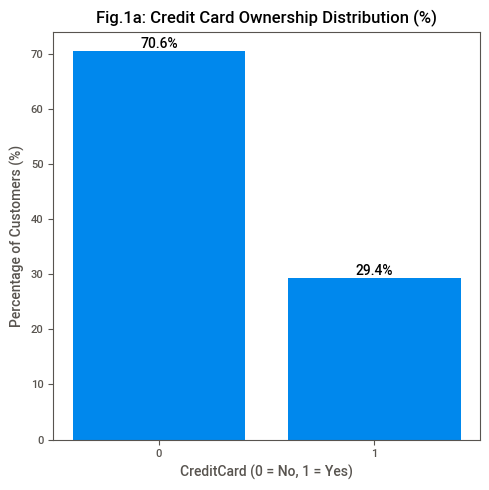

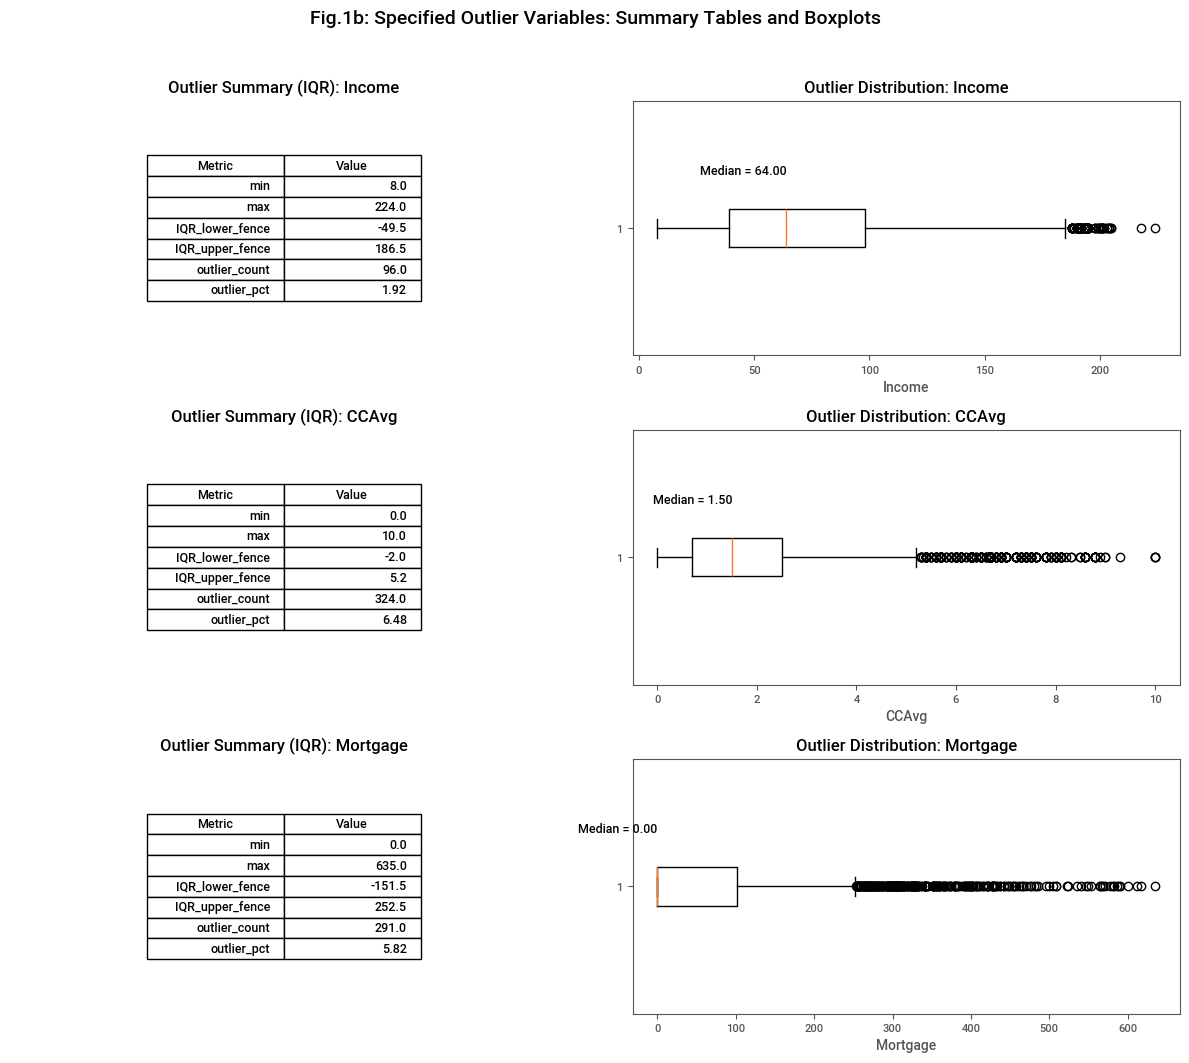

In [10]:
# -- Visualizing Credit Card Ownership Distribution

cc_pct = Loan["CreditCard"].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(5,5))
plt.bar(cc_pct.index.astype(str), cc_pct.values)

for i, v in enumerate(cc_pct.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.title("Fig.1a: Credit Card Ownership Distribution (%)")
plt.xlabel("CreditCard (0 = No, 1 = Yes)")
plt.ylabel("Percentage of Customers (%)")
plt.tight_layout()
plt.show()


# -- visualize outliers from specified columns

outlier_cols = ["Income", "CCAvg", "Mortgage"]   # from profiling report
plot_outliers_from_columns(df, ["Income", "CCAvg", "Mortgage"])


* In particular, `CreditCard` displays a high proportion of no credit card ownership (approximately 71% of customer (Fig.1a)), which is a potentially differentiating behavioural attribute and may help separate more financially engaged customers from others.

* Likewise, `Mortgage` displays a high proportion of zero values (Fig.1b), which is structurally meaningful and indicative of customers without mortgage commitments.

* Binary and categorical variables (e.g., `CD_Account`, `Securities_Account`, `CreditCard`, `Online`) show pronounced class imbalance; however, this imbalance reflects genuine customer behaviour rather than data quality issues.

* No univariate anomalies requiring correction were identified at this stage.

---

### Section 6.2: Bivariate Analysis (Predictors vs Target)
* This focuses on understanding how certain individual predictors (`Income`, Credit Card Spend(`CCAvg`) , `Mortgage` , `Age` , `Education`) relate to the target variable, `Personal_Loan`.

* Below presents a comparative bivariate analysis of key financial variables (personal loan purchase rates) against personal loan uptake and by age group and education level.<br>
>- Clear separation is observed between loan purchasers and non-purchasers across Income, CCAvg, and Mortgage, reinforcing their relevance for predictive modelling in Fig.2.
>- Fig.3 shows a non-linear life-stage effects and a monotonic relationship with education.

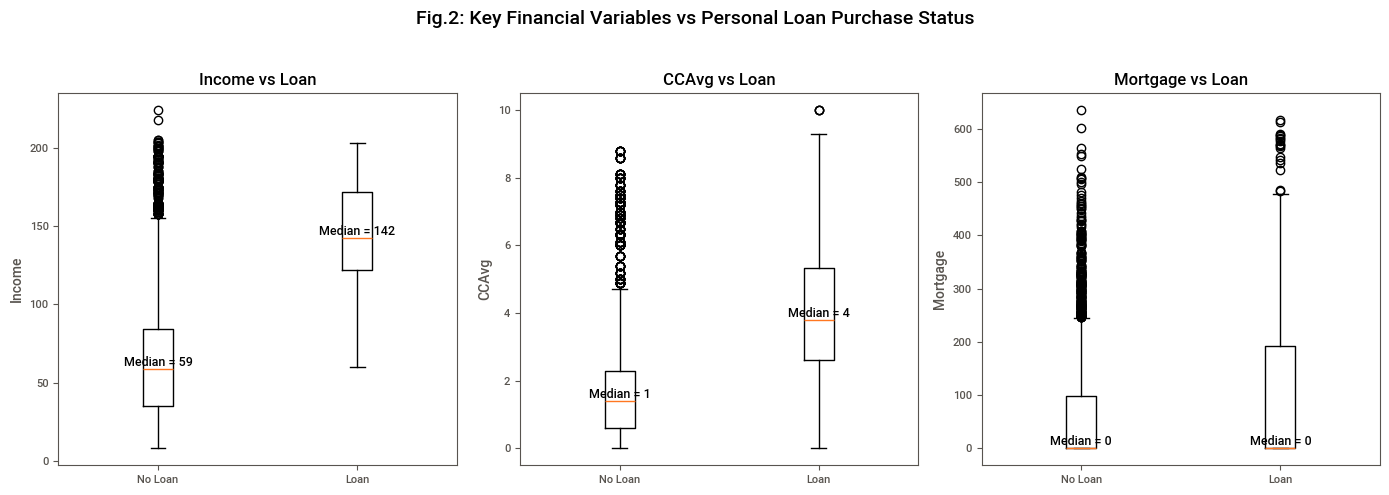

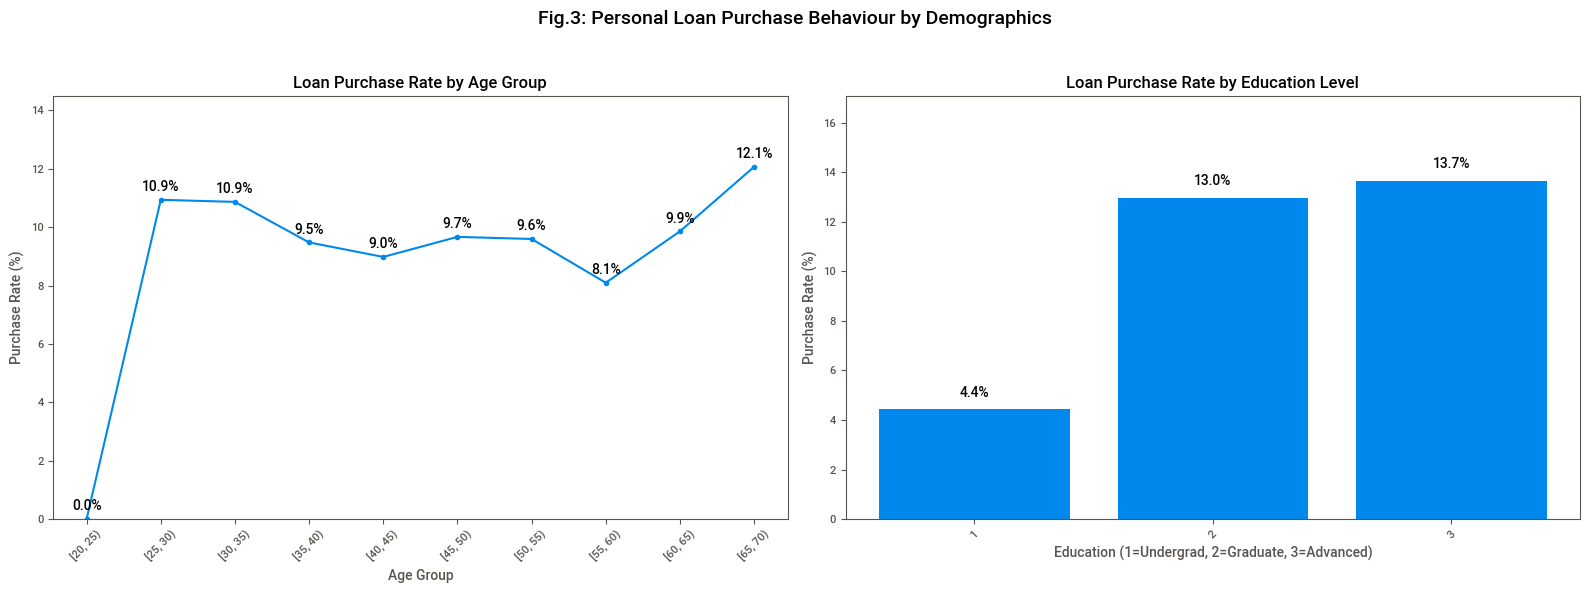

In [11]:
# Plot boxplots for selected bivariate features against Personal_Loan target

bivariate_features = ["Income", "CCAvg", "Mortgage"]
plot_numeric_vs_target_subplots(Loan, bivariate_features)

# Plot purchase rate subplots by Age group and Education level
specs = [
    {
        "name": "Loan Purchase Rate by Age Group",
        "col": "Age",
        "kind": "binned",
        "bins": [20,25,30,35,40,45,50,55,60,65,70],
        "xlabel": "Age Group"
    },
    {
        "name": "Loan Purchase Rate by Education Level",
        "col": "Education",
        "kind": "categorical",
        "xlabel": "Education (1=Undergrad, 2=Graduate, 3=Advanced)"
    }
]

plot_purchase_rate_grid(
    df=Loan,
    target="Personal_Loan",
    specs=specs,
    cols=2,
    figsize=(16,6),
    suptitle="Fig.3: Personal Loan Purchase Behaviour by Demographics"
)

#### Observation

- Loan purchasers have much higher incomes than non‑purchasers, along with higher credit‑card spending and larger mortgages, indicating strong financial‑behaviour separation between the groups.  
- Loan purchase rates are highest among middle-aged customers (30–55), but also rise again for ages 65–70, suggesting non-linear life-stage effects.  
- Education level strongly correlates with loan uptake: rates increase from 4.4% (Undergrad) to 13.7% (Advanced), indicating higher financial confidence or income potential.  
- **These bivariate patterns confirm strong predictors, but interdependencies among features warrant multivariate analysis to assess overlap and interactions.**

---

### Section 6.3: Multivariate Analysis (Feature–Feature Relationships)

- Assesses predictor relationships to uncover redundancy and interaction effects.

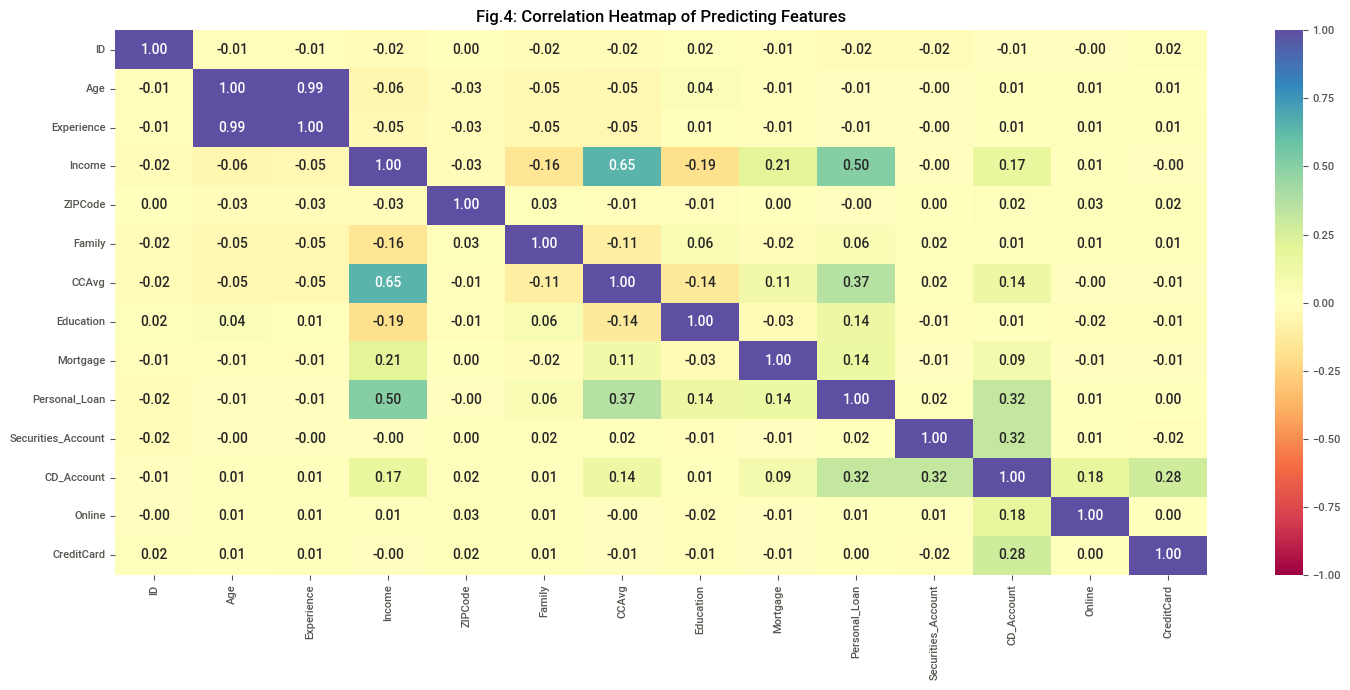

In [12]:
# Correlation heatmap
plt.figure(figsize=(15, 7))

corr_matrix = Loan.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.title("Fig.4: Correlation Heatmap of Predicting Features")
plt.tight_layout()
plt.show()

**Observation**
- Strong correlations exist between `Age`– `Experience` and `Income` – `CCAvg`, indicating potential multicollinearity that may impact model stability.
- These correlations reflect structural traits, not data quality issues, and will be addressed during modelling.
- No higher-order interaction modelling is performed at this stage.
---

### Transition to Data Preprocessing

- Univariate, bivariate, and multivariate analyses reveal skewed distributions, valid outliers, class imbalance, and correlated features as core dataset traits.
- These insights guide preprocessing, where transformations, scaling, and encoding will be applied to support robust modelling without altering data integrity.

---

## Section 7: Data Preprocessing & Preparation for Modelling

- The preprocessing approach is guided by insights from the profiling report [(Appendix A)](Automated_Data_Profiling_Report.html) and all exploratory analyses.
- The goal is to ready the data for modelling while preserving its structure and preventing information loss or leakage.

### Section 7.1: Data Preprocessing Summary

| Preprocessing Area      | Observation (Profiling & EDA)                          | Action Taken                                        | Rationale                                              |
| ----------------------- | ------------------------------------------------------ | --------------------------------------------------- | ------------------------------------------------------ |
| Data completeness       | No missing values or duplicates                        | No cleaning applied                                 | Preserves original data integrity                      |
| Identifier variable     | `ID` is non-predictive                                 | Dropped                                             | Prevents noise and leakage                             |
| Target variable         | `Personal_Loan` is imbalanced                          | Kept; stratified split                              | Maintains true class proportions                       |
| Financial distributions | Skewed `Income`, `CCAvg`, `Mortgage` with outliers     | Passed through unchanged                            | Trees handle skew and outliers via threshold splits    |
| Experience variable     | Negative values; fully correlated with `Age`           | Dropped                                             | Removes artefact and redundancy                        |
| ZIPCode feature         | High-cardinality numeric identifier                    | Converted to string; extracted first 2 digits (`ZIP2`) | Retains regional signal, reduces dimensionality        |
| Categorical features    | `Education` and `ZIP2` categorical                     | One-hot encoded                                     | Avoids false ordering assumptions                      |
| Binary variables        | Already 0/1 encoded                                    | Passed through unchanged                            | Model-ready                                            |

---

- *Preprocessing was aligned with decision‑tree behaviour, prioritising threshold-based splits and correct categorical handling rather than distributional assumptions.*

- *Outliers were retained as meaningful, multicollinearity was accepted structurally, and categorical variables were encoded to support clean rule formation.*

- *ZIPCode engineering preserved regional information without sparsity, and class imbalance was addressed later through class‑weighted learning.*


In [13]:
# Feature engineering: # ZIPCode -> ZIP2 
# ---------------------------
if "ZIPCode" in Loan.columns:
    Loan["ZIP2"] = Loan.pop("ZIPCode").astype(str).str.zfill(5).str[:2]

print("ZIP2 unique values (overall):", Loan["ZIP2"].nunique())
print(Loan["ZIP2"].unique().tolist())  # show unique values

ZIP2 unique values (overall): 7
['91', '90', '94', '92', '93', '95', '96']


### Section 7.2: Data Preparation for Modeling

In [15]:
# Drop ID (pure identifier) & Experience (as it is perfectly correlated with Age) Columns
Loan = Loan.drop(["ID", "Experience"], axis=1)
# Loan.info()

In [17]:
# Split features/target for modeling

TARGET  = "Personal_Loan"
# ---------------------------
X = Loan.drop(columns=[TARGET ])
y = Loan[TARGET]

# Stratified train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")  

Training set size: 3500 samples
Test set size: 1500 samples


In [18]:
# Feature groups (aligned with preprocessing decisions)
# ---------------------------
skewed_cols = [c for c in ["Income", "CCAvg", "Mortgage"] if c in X.columns]
binary_cols = [c for c in ["Securities_Account", "CD_Account", "Online", "CreditCard"] if c in X.columns]
categorical_cols = [c for c in ["Education", "ZIP2", "Family"] if c in X.columns]


# Remaining numeric columns (exclude skewed + binary)
numeric_cols = (
    X.select_dtypes(include="number")
     .columns.difference(skewed_cols + binary_cols)
     .tolist()
)

In [19]:
# Transformers / Preprocessor
# ---------------------------

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("skewed", "passthrough", skewed_cols),  
        ("numeric", "passthrough", numeric_cols),
        ("binary", "passthrough", binary_cols),
        ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
    ],
    remainder="drop"
)

# Apply preprocessing
X_train_prepared = preprocessor_tree.fit_transform(X_train)
X_test_prepared = preprocessor_tree.transform(X_test)

print("Done.")
print("ZIP2 unique values (overall):", Loan["ZIP2"].nunique() if "ZIP2" in Loan.columns else "N/A")
print("Train shape:", X_train_prepared.shape)
print("Test shape:", X_test_prepared.shape)

print("Percentage of classes in training set:", y_train.value_counts(normalize=True))
print("Percentage of classes in test set:", y_test.value_counts(normalize=True))

Done.
ZIP2 unique values (overall): 7
Train shape: (3500, 21)
Test shape: (1500, 21)
Percentage of classes in training set: Personal_Loan
0    0.904
1    0.096
Name: proportion, dtype: float64
Percentage of classes in test set: Personal_Loan
0    0.904
1    0.096
Name: proportion, dtype: float64


In [20]:
# Checks: Convert preprocessed training data to DataFrame for easier inspection

feature_names = [n.split("__", 1)[-1] for n in preprocessor_tree.get_feature_names_out()]

X_train_prepared_df = pd.DataFrame(
    preprocessor_tree.fit_transform(X_train),
    columns=feature_names
)

print(len(feature_names), X_train_prepared_df.shape[1])

X_train_prepared_df

21 21


,Income,CCAvg,Mortgage,Age,Education,Family,Securities_Account,CD_Account,Online,CreditCard,...,Education_3,ZIP2_91,ZIP2_92,ZIP2_93,ZIP2_94,ZIP2_95,ZIP2_96,Family_2,Family_3,Family_4
0,81.0,2.67,0.0,47.0,2.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,31.0,1.00,0.0,49.0,1.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,65.0,3.70,0.0,56.0,1.0,2.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,155.0,7.30,0.0,50.0,1.0,1.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,58.0,2.80,0.0,35.0,1.0,3.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495,182.0,5.80,0.0,37.0,3.0,3.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3496,91.0,1.50,289.0,36.0,3.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3497,131.0,2.70,0.0,57.0,1.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3498,83.0,1.00,0.0,40.0,3.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


---

## Section 8: Model Building

With the dataset fully prepared, the next step is to build a predictive model that can identify customers with a high likelihood of taking a personal loan. Because the target variable is strongly imbalanced — *buyers form only a small minority* — the modelling strategy prioritises minority‑class detection while maintaining model stability and interpretability.

To address this imbalance, a **class‑weighted decision tree classifier** is used, ensuring that misclassifying a buyer carries a higher penalty than misclassifying a non‑buyer. Overfitting is controlled through **maximum depth** and **minimum samples per leaf**, with both hyperparameters tuned via a focused grid search. **PR‑AUC (Average Precision)** is used as the primary optimisation metric, as it best reflects minority‑class performance without relying on a fixed threshold.

Because accuracy is misleading under imbalance, evaluation focuses on metrics that reflect the model’s ability to correctly identify buyers:

- **Recall (class 1):** essential for capturing potential buyers  
- **Precision (class 1):** supports efficient targeting  
- **F1‑score:** balances precision and recall  
- **PR‑AUC:** preferred threshold‑free metric for imbalanced data  
- **ROC‑AUC:** secondary reference metric  
- **Confusion Matrix:** clarifies business trade-offs between false positives and false negatives  

This modelling setup ensures alignment with the bank’s operational goals: maximising the identification of genuine loan prospects while maintaining campaign efficiency.

### Function to compute classification model performance metrics

In [21]:
# Function to run all diagnostics for Decision Tree Classifier

def run_all_tree_diagnostics(
    clf,
    X_test_prep,
    y_test_prep,
    feature_names=None,
    top_n=10,
    max_depth=None
):
    """
    Run evaluation + metrics table (styled) + confusion matrix (chart with %)
    + feature importance (table + labelled bar chart)
    + tree plot + textual rule extraction
    for a fitted DecisionTreeClassifier.
    """

    # --------------------
    # Predictions
    # --------------------
    y_pred = clf.predict(X_test_prep)
    y_prob = clf.predict_proba(X_test_prep)[:, 1] if hasattr(clf, "predict_proba") else None

    # --------------------
    # Metrics summary table
    # --------------------
    report = classification_report(y_test_prep, y_pred, output_dict=True, zero_division=0)

    metrics = {
        "Accuracy": report["accuracy"],
        "Precision (Loan=1)": report["1"]["precision"],
        "Recall (Loan=1)": report["1"]["recall"],
        "F1-score (Loan=1)": report["1"]["f1-score"]
    }

    if y_prob is not None:
        metrics["ROC-AUC"] = roc_auc_score(y_test_prep, y_prob)
        metrics["PR-AUC"] = average_precision_score(y_test_prep, y_prob)

    metrics_df = (
        pd.DataFrame.from_dict(metrics, orient="index", columns=["Value"])
          .round(2)
          .reset_index()
          .rename(columns={"index": "Metric"})
    )

    display(
        metrics_df.style
            .format({"Value": "{:.2f}"})
            .set_properties(subset=["Metric"], **{"width": "260px", "font-weight": "bold"})
            .set_properties(subset=["Value"], **{"width": "90px", "text-align": "right"})
    )

    # --------------------
    # Confusion matrix (chart with percentages)
    # --------------------
    cm = confusion_matrix(y_test_prep, y_pred)

    labels = np.asarray(
        [f"{item}\n{item / cm.sum():.2%}" for item in cm.flatten()]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=labels,
        fmt="",
        cmap="Blues",
        xticklabels=["No Loan", "Loan"],
        yticklabels=["No Loan", "Loan"]
    )
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    # --------------------
    # Feature importance (table)
    # --------------------
    if feature_names is None:
        feature_names = [f"X{i}" for i in range(X_test_prep.shape[1])]

    importance_df = (
        pd.DataFrame({
            "Feature": feature_names,
            "Importance": clf.feature_importances_
        })
        .sort_values("Importance", ascending=False)
        .round(2)
    )

    # display(importance_df.head(top_n))

    # --------------------
    # Feature importance bar chart (WITH data labels)
    # --------------------
    top_features = importance_df.head(top_n)

    plt.figure(figsize=(9, 5))
    bars = plt.barh(top_features["Feature"], top_features["Importance"])
    plt.gca().invert_yaxis()
    plt.title(f"Top {top_n} Feature Importances")
    plt.xlabel("Importance")

    for bar in bars:
        width = bar.get_width()
        plt.text(
            width,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.2f}",
            va="center",
            ha="left",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

    # --------------------
    # Tree plot
    # --------------------
    plt.figure(figsize=(18, 8))
    plot_tree(
        clf,
        feature_names=feature_names,
        class_names=["No Loan", "Loan"],
        filled=True,
        rounded=True,
        max_depth=max_depth,
        precision=2
    )
    plt.title(f"Decision Tree (shown up to depth={max_depth})")
    plt.show()

    # --------------------
    # Textual decision rules
    # --------------------
    rules = tree.export_text(
    clf,
    feature_names=feature_names,
    show_weights=True
    )
    
    rules_2dp = re.sub(r"(\d+\.\d+)", lambda m: f"{float(m.group()):.2f}", rules)
    print("\nDecision Tree Rules:\n")
    print(rules_2dp)


    return metrics_df , importance_df



### Section 8.1: Decision Tree (sklearn default)

In [22]:
# Baseline model: Decision Tree Classifier (sklearn default)
clf_def = DecisionTreeClassifier(criterion="gini", random_state=1)
clf_def.fit(X_train_prepared, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

#### Step 1: Optional training-set check (diagnostic check for overfitting)

Training performance:


,Metric,Value
0,Accuracy,1.00
1,Precision (Loan=1),1.00
2,Recall (Loan=1),1.00
3,F1-score (Loan=1),1.00
4,ROC-AUC,1.00
5,PR-AUC,1.00


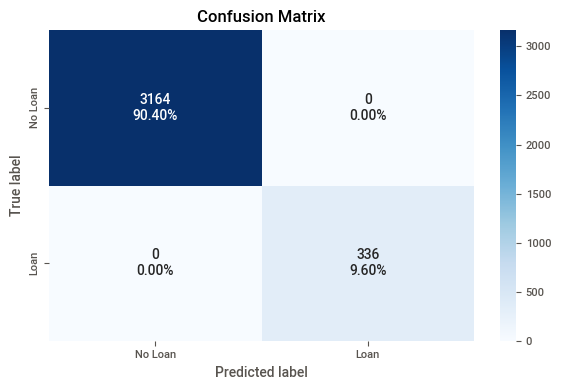

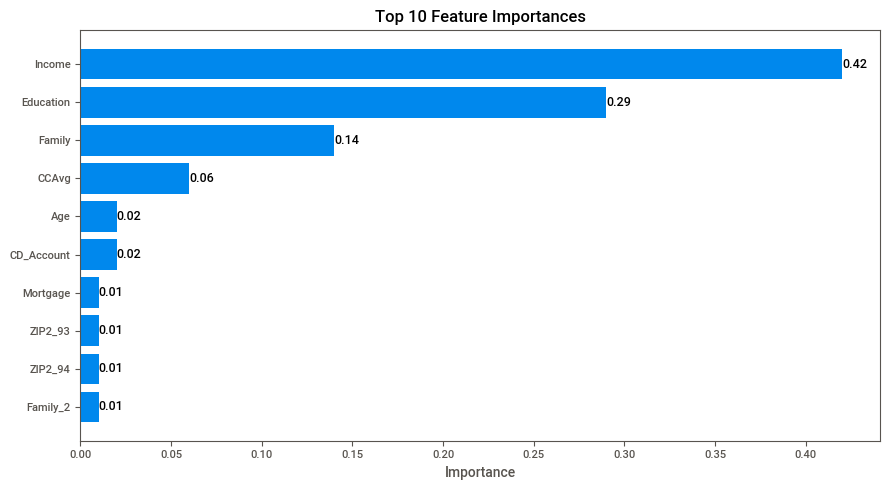

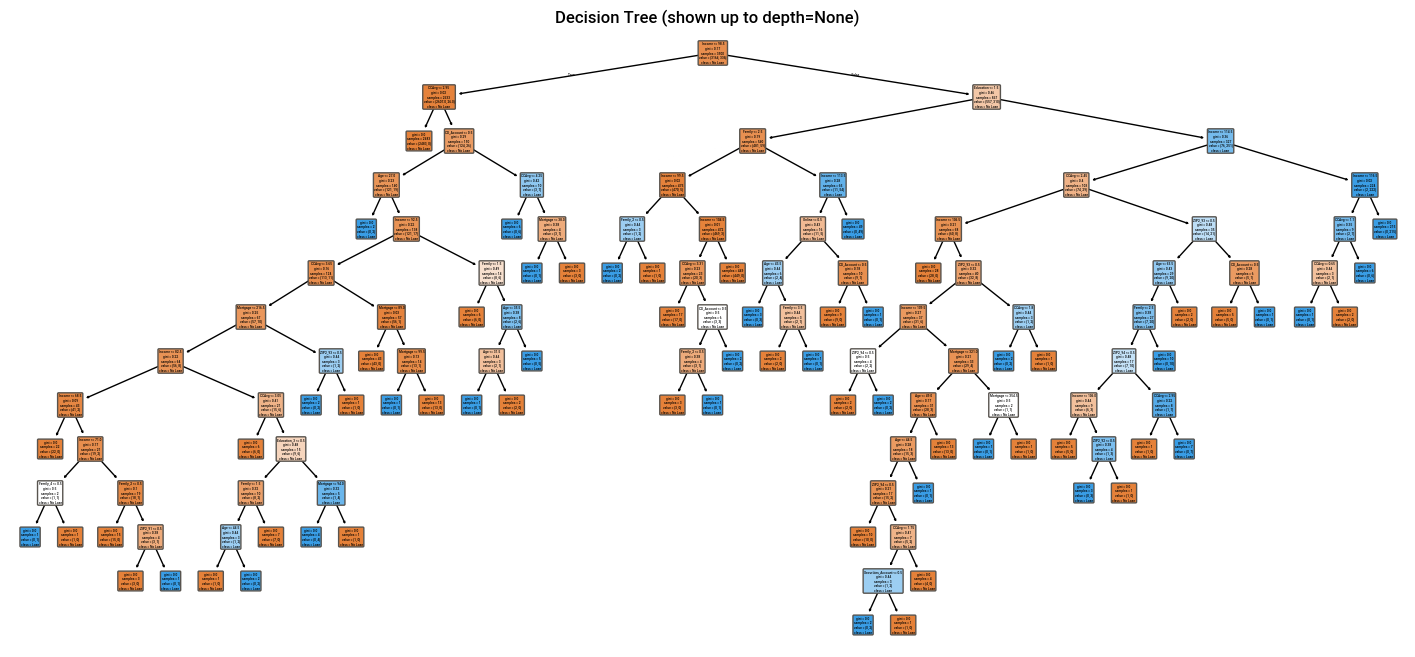


Decision Tree Rules:

|--- Income <= 98.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2483.00, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- Age <= 27.00
|   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |--- Age >  27.00
|   |   |   |   |--- Income <= 92.50
|   |   |   |   |   |--- CCAvg <= 3.65
|   |   |   |   |   |   |--- Mortgage <= 216.50
|   |   |   |   |   |   |   |--- Income <= 82.50
|   |   |   |   |   |   |   |   |--- Income <= 68.50
|   |   |   |   |   |   |   |   |   |--- weights: [22.00, 0.00] class: 0
|   |   |   |   |   |   |   |   |--- Income >  68.50
|   |   |   |   |   |   |   |   |   |--- Income <= 71.00
|   |   |   |   |   |   |   |   |   |   |--- Family_4 <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |   |   |   |   |   |--- Family_4 >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [1.00, 0.00] class: 0
|   |   |   |   |   |   | 

In [23]:
# Step 1: Baseline Model Training-set check 
print("Training performance:")
clf_train_metrics, _ = run_all_tree_diagnostics(
    clf=clf_def,
    X_test_prep=X_train_prepared,
    y_test_prep=y_train,
    feature_names=feature_names,
    top_n=10,
    max_depth=None
)

**Results Interpretation**

1. **Perfect Training Performance**: The model achieved 100% across all metrics (accuracy, precision, recall, F1, ROC‑AUC, PR‑AUC), indicating flawless classification on the training set.

2. **Confusion Matrix**: No false positives or false negatives — all 336 loan buyers and 3164 non‑buyers were correctly classified.

3. **Feature Importance**: Top predictors were **Income**, **Education**, and **Family size**, confirming earlier insights about financial and demographic influence.

4. **Model Behaviour**: Tree splits reflect threshold‑based decisions, with financial magnitude and categorical features driving most of the separation.

5. **Caution on Overfitting**: Perfect scores suggest potential overfitting; validation on unseen data is essential to confirm generalisation.


#### Step 2: Checking Base Model performance on test data

Test performance:


,Metric,Value
0,Accuracy,0.98
1,Precision (Loan=1),0.84
2,Recall (Loan=1),0.94
3,F1-score (Loan=1),0.89
4,ROC-AUC,0.96
5,PR-AUC,0.80


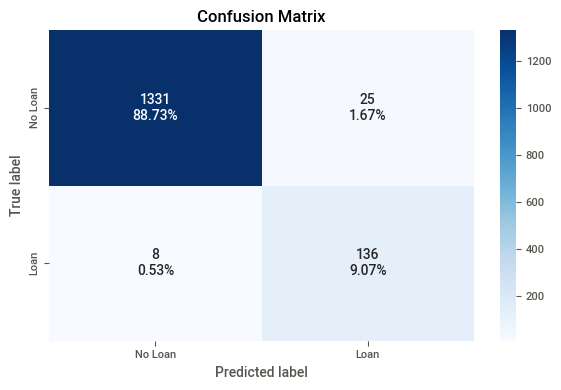

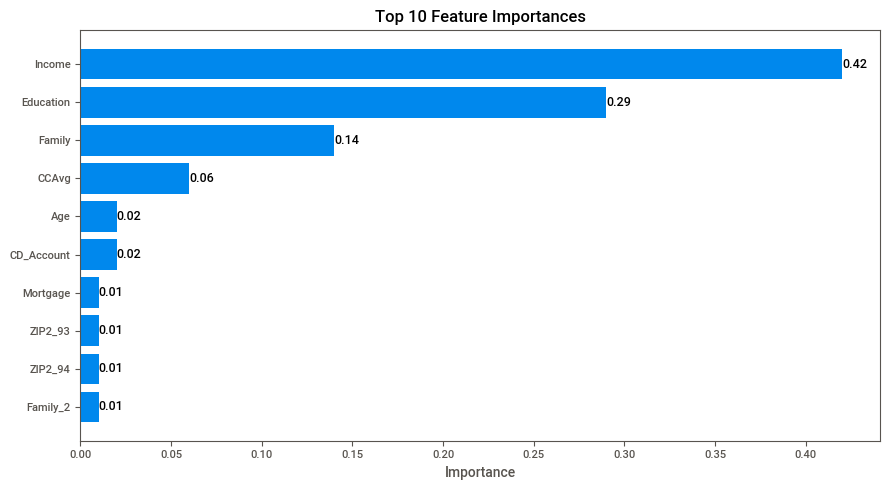

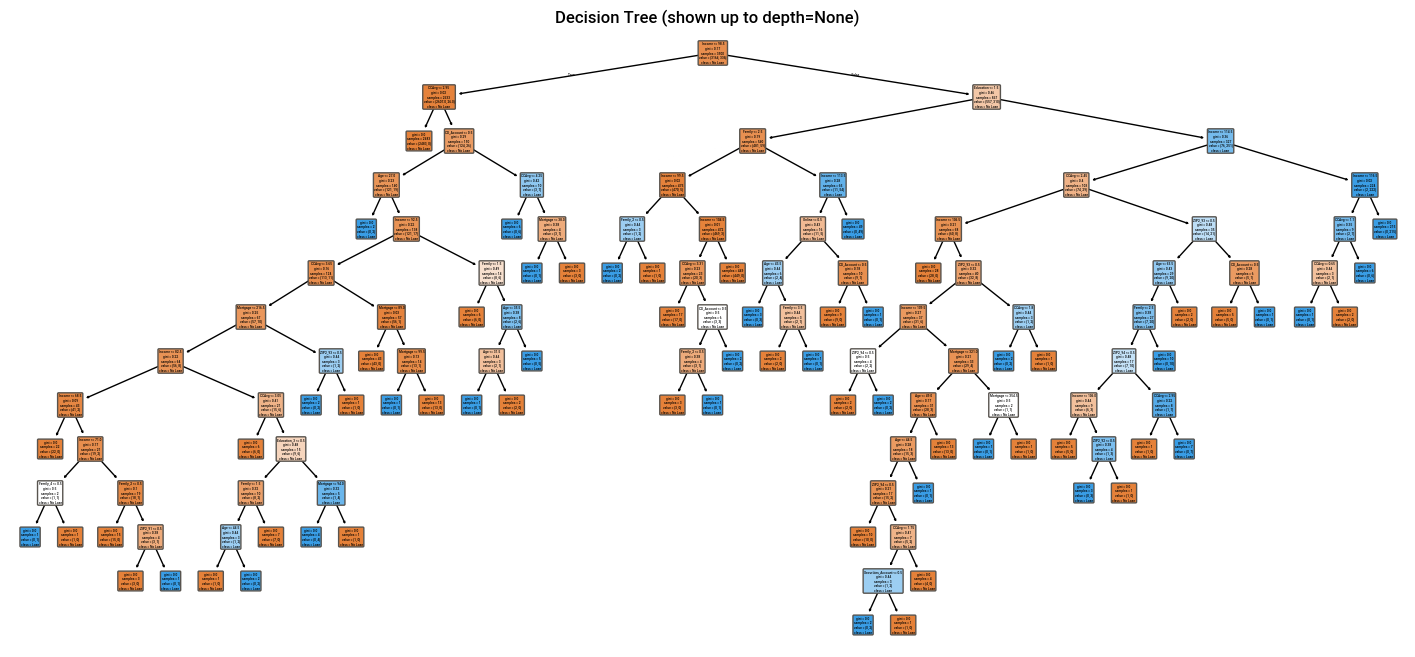


Decision Tree Rules:

|--- Income <= 98.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2483.00, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- Age <= 27.00
|   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |--- Age >  27.00
|   |   |   |   |--- Income <= 92.50
|   |   |   |   |   |--- CCAvg <= 3.65
|   |   |   |   |   |   |--- Mortgage <= 216.50
|   |   |   |   |   |   |   |--- Income <= 82.50
|   |   |   |   |   |   |   |   |--- Income <= 68.50
|   |   |   |   |   |   |   |   |   |--- weights: [22.00, 0.00] class: 0
|   |   |   |   |   |   |   |   |--- Income >  68.50
|   |   |   |   |   |   |   |   |   |--- Income <= 71.00
|   |   |   |   |   |   |   |   |   |   |--- Family_4 <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |   |   |   |   |   |--- Family_4 >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [1.00, 0.00] class: 0
|   |   |   |   |   |   | 

In [24]:
# Step 1: Training-set check 
print("Test performance:")
clf_test_metrics, _ = run_all_tree_diagnostics(
    clf=clf_def,
    X_test_prep=X_test_prepared,
    y_test_prep=y_test,
    feature_names=feature_names,
    top_n=10,
    max_depth= None
)

**Results Interpretation**

The model generalises well to unseen data, maintaining strong performance across all key metrics:

1. **Strong Generalisation**: The model performs well on test data with high recall (0.94), precision (0.84), and F1‑score (0.89), confirming its ability to identify loan buyers accurately and efficiently.
2. **Confusion Matrix Insights:** Out of 144 loan buyers, 136 were correctly identified, with only 8 missed. False positives were minimal (25), supporting both lead capture and campaign efficiency.
3. **Feature Importance:** Top predictors include `Income`, `Education`, and `Family size`, followed by `CCAvg` and `CD_Account`—highlighting financial capacity and credit engagement as key drivers.
4. **Decision Tree Behaviour:** The tree uses threshold splits on financial and demographic features, forming interpretable rules that align with business logic (e.g., high income + graduate education → likely buyer).
5. **Business Alignment:** The model balances precision and recall, supports targeted outreach, and offers transparent decision paths—making it suitable for operational deployment.

*These results suggest the model is both accurate and reliable, with minimal overfitting and strong alignment to business goals.*

### Section 8.2: Model Performance Improvement

- The original decision tree fit the training data perfectly, indicating high variance and overfitting. Because decision trees grow greedily and tend to capture noise, both pre‑pruning and post‑pruning were considered as strategies to improve generalisation.

- Pre‑pruning constrains the tree during training by limiting depth or minimum leaf size, preventing unnecessary complexity and reducing the risk of overfitting from the outset.

- Post‑pruning takes the opposite approach: the tree is allowed to grow fully, and then branches that do not improve validation performance are trimmed back. This can yield a more balanced model but requires additional computation and validation.

#### Section 8.2.1: Pre-Pruning the Decision Tree (GridSearch (recommended scoring = PR‑AUC for buyers))

- GridSearch tunes key pre‑pruning hyperparameters while using PR‑AUC to account for class imbalance, selecting the best estimator. It integrates directly with the preprocessed training data, ensuring a smooth, plug‑and‑play modelling workflow.

In [25]:
# Hyperparameter tuning with GridSearchCV (Pre-pruning)
# ---------------------------

# Base tree (imbalance-aware)
dt = DecisionTreeClassifier(
    criterion="gini",
    class_weight="balanced",
    random_state=42
)

# Dynamic parameter grid (pre-pruning)
param_grid = {
    "max_depth": [2, 3, 4, 5, 6],
    "min_samples_split": [10, 30, 50, 70],
    "min_samples_leaf": [10, 25, 50],
    "max_leaf_nodes": [50, 75, 150, 250]
}

# Optimise for imbalanced classification (PR-AUC) with a cross validation(cv) of 5 folds
grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring="average_precision",   # PR-AUC
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_prepared, y_train)

clf_pre_pruned = grid.best_estimator_
print("Best params:", grid.best_params_)
print("Best CV PR-AUC:", round(grid.best_score_, 3))

# Top CV results table
cv_results = pd.DataFrame(grid.cv_results_)
results_table = (
    cv_results[["mean_test_score", "std_test_score", "params"]]
    .rename(columns={"mean_test_score": "mean_PR_AUC", "std_test_score": "std_PR_AUC"})
    .sort_values("mean_PR_AUC", ascending=False)
    .head(5)
)

results_table


Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Best params: {'max_depth': 4, 'max_leaf_nodes': 50, 'min_samples_leaf': 10, 'min_samples_split': 10}
Best CV PR-AUC: 0.951


,mean_PR_AUC,std_PR_AUC,params
120,0.950671,0.024737,"{'max_depth': 4, 'max_leaf_nodes': 150, 'min_s..."
132,0.950671,0.024737,"{'max_depth': 4, 'max_leaf_nodes': 250, 'min_s..."
121,0.950671,0.024737,"{'max_depth': 4, 'max_leaf_nodes': 150, 'min_s..."
109,0.950671,0.024737,"{'max_depth': 4, 'max_leaf_nodes': 75, 'min_sa..."
108,0.950671,0.024737,"{'max_depth': 4, 'max_leaf_nodes': 75, 'min_sa..."


Pre-pruned Tree - Training performance:


,Metric,Value
0,Accuracy,0.95
1,Precision (Loan=1),0.66
2,Recall (Loan=1),0.97
3,F1-score (Loan=1),0.78
4,ROC-AUC,1.00
5,PR-AUC,0.96


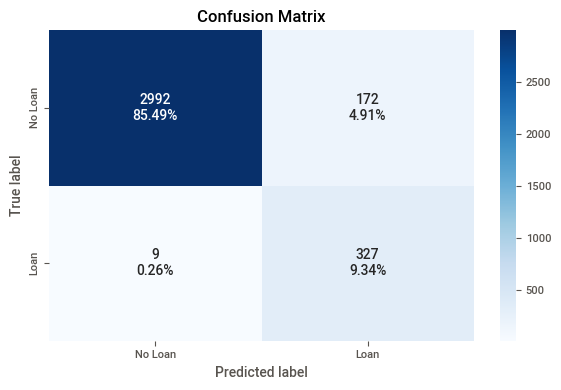

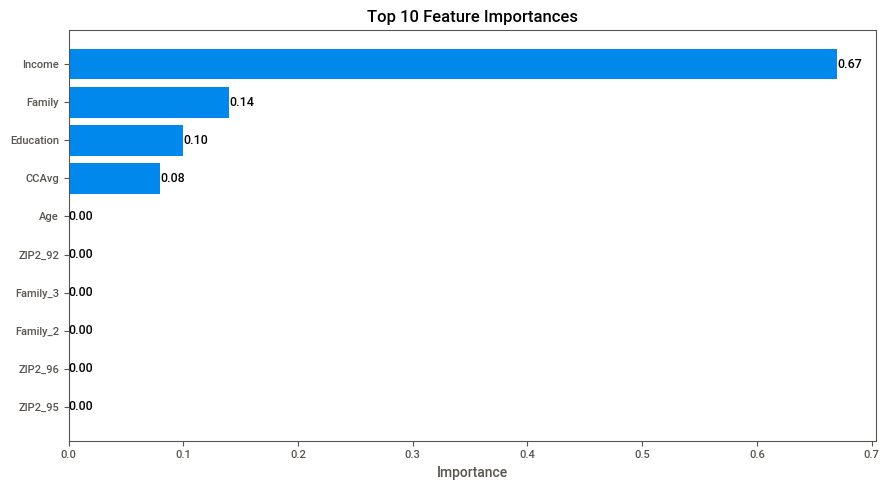

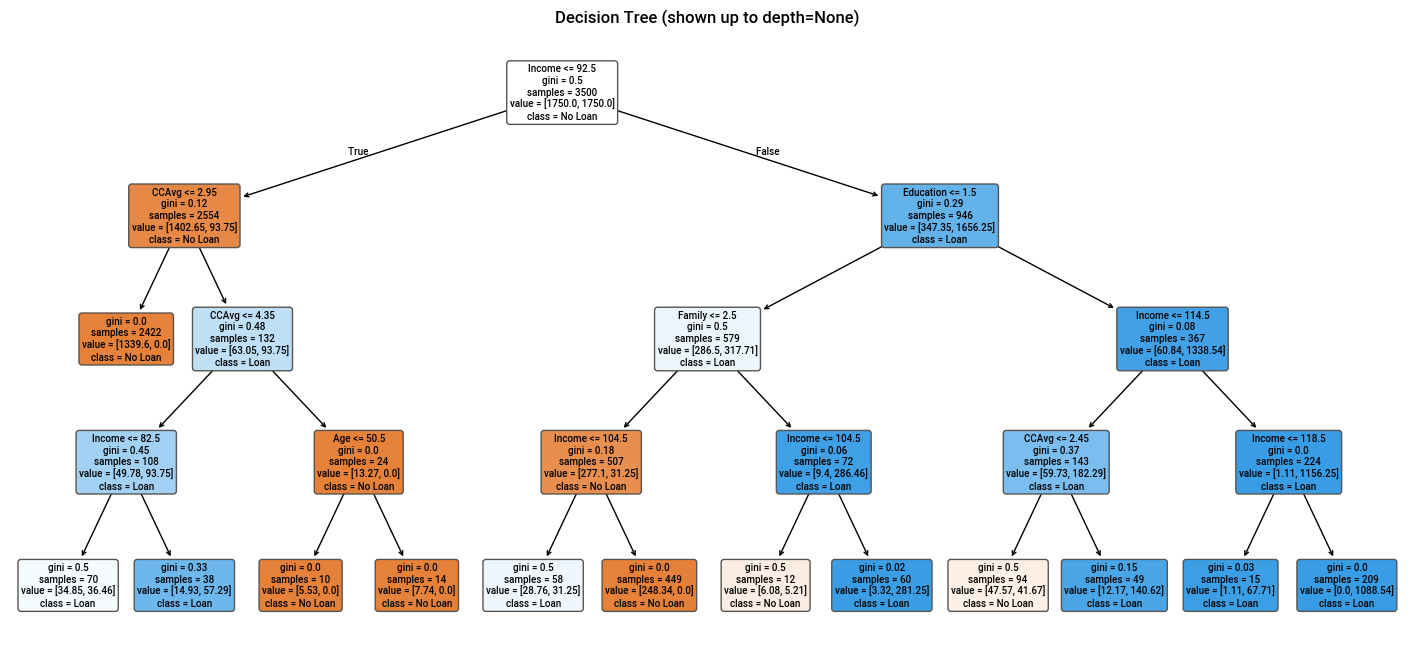


Decision Tree Rules:

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1339.60, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CCAvg <= 4.35
|   |   |   |--- Income <= 82.50
|   |   |   |   |--- weights: [34.85, 36.46] class: 1
|   |   |   |--- Income >  82.50
|   |   |   |   |--- weights: [14.93, 57.29] class: 1
|   |   |--- CCAvg >  4.35
|   |   |   |--- Age <= 50.50
|   |   |   |   |--- weights: [5.53, 0.00] class: 0
|   |   |   |--- Age >  50.50
|   |   |   |   |--- weights: [7.74, 0.00] class: 0
|--- Income >  92.50
|   |--- Education <= 1.50
|   |   |--- Family <= 2.50
|   |   |   |--- Income <= 104.50
|   |   |   |   |--- weights: [28.76, 31.25] class: 1
|   |   |   |--- Income >  104.50
|   |   |   |   |--- weights: [248.34, 0.00] class: 0
|   |   |--- Family >  2.50
|   |   |   |--- Income <= 104.50
|   |   |   |   |--- weights: [6.08, 5.21] class: 0
|   |   |   |--- Income >  104.50
|   |   |   |   |--- weights: [3.32, 281.25] class: 1
|   |--- Educatio

In [26]:
# evaluation on train set
print("Pre-pruned Tree - Training performance:")
clf_pre_pruned_train_metrics, _ = run_all_tree_diagnostics(
    clf=clf_pre_pruned,
    X_test_prep=X_train_prepared,
    y_test_prep=y_train,
    feature_names=feature_names,
    max_depth=None
)

**Results Interpretation (Pre-Pruned Tree — Training Evaluation Summary)**

The pre-pruned decision tree shows strong generalisation compared to the base model, with reduced overfitting and improved balance between precision and recall.

1. **Balanced Performance:** The pre-pruned tree achieved high recall (0.97) and strong PR-AUC (0.96), confirming its ability to identify loan buyers effectively while maintaining generalisation. Precision (0.66) is lower than the base model, reflecting a trade-off for broader capture.
2. **Confusion Matrix Insights:** Out of 336 actual buyers, 327 were correctly identified, with only 9 missed. False positives (172) are higher than the base model, but acceptable given the gain in recall and overall campaign reach.
3. **Feature Importance:** The most influential features are `Income` (~0.67), `Family` (~0.14), and `Education` (~0.10), followed by `CCAvg` and `Age`. This confirms that financial capacity and household structure are key drivers of loan uptake.
4. **Decision Tree Rules:** The tree’s root split is on `Income` ≤ 92.5, with subsequent branches involving `Family` size, `Education` level, and `CCAvg`. These rules form interpretable pathways that align with business logic (e.g., higher income and graduate education → likely buyer).
5. **Generalisation Over Memorisation:** Unlike the base model, which fit the training data perfectly, the pre-pruned tree sacrifices some precision to avoid overfitting. This results in a more realistic and deployable model


Pre-pruned Tree - Test performance:


,Metric,Value
0,Accuracy,0.95
1,Precision (Loan=1),0.64
2,Recall (Loan=1),0.99
3,F1-score (Loan=1),0.78
4,ROC-AUC,1.00
5,PR-AUC,0.96


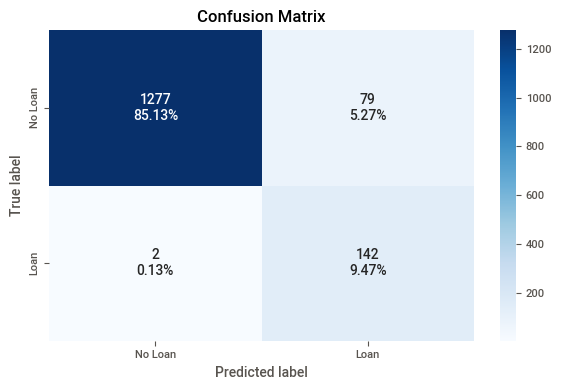

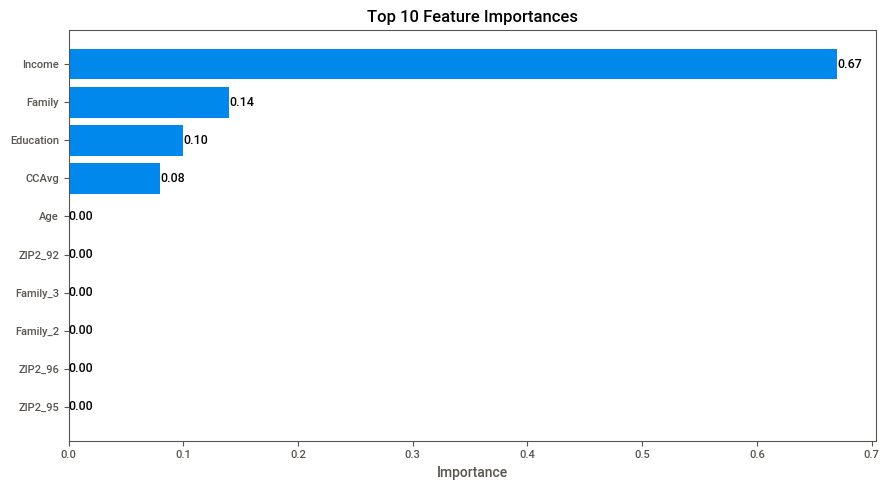

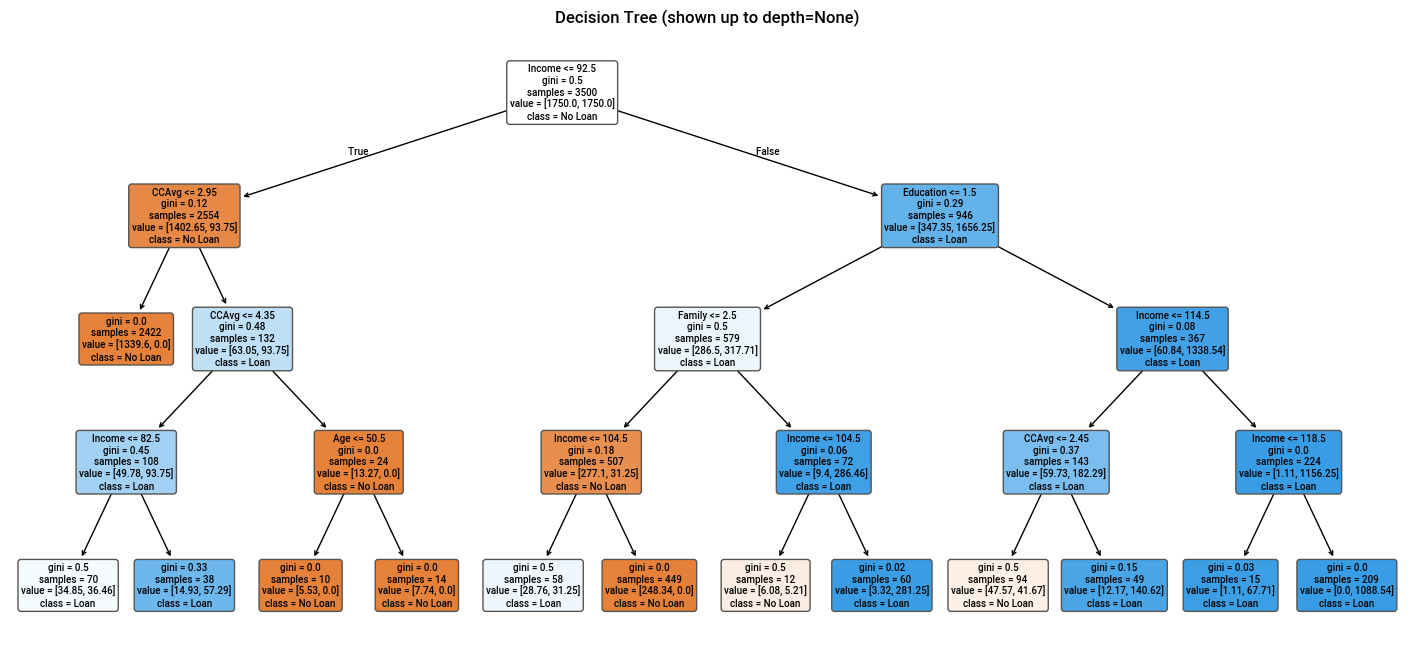


Decision Tree Rules:

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1339.60, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CCAvg <= 4.35
|   |   |   |--- Income <= 82.50
|   |   |   |   |--- weights: [34.85, 36.46] class: 1
|   |   |   |--- Income >  82.50
|   |   |   |   |--- weights: [14.93, 57.29] class: 1
|   |   |--- CCAvg >  4.35
|   |   |   |--- Age <= 50.50
|   |   |   |   |--- weights: [5.53, 0.00] class: 0
|   |   |   |--- Age >  50.50
|   |   |   |   |--- weights: [7.74, 0.00] class: 0
|--- Income >  92.50
|   |--- Education <= 1.50
|   |   |--- Family <= 2.50
|   |   |   |--- Income <= 104.50
|   |   |   |   |--- weights: [28.76, 31.25] class: 1
|   |   |   |--- Income >  104.50
|   |   |   |   |--- weights: [248.34, 0.00] class: 0
|   |   |--- Family >  2.50
|   |   |   |--- Income <= 104.50
|   |   |   |   |--- weights: [6.08, 5.21] class: 0
|   |   |   |--- Income >  104.50
|   |   |   |   |--- weights: [3.32, 281.25] class: 1
|   |--- Educatio

In [27]:
# Final evaluation on test set
print("Pre-pruned Tree - Test performance:")
clf_pre_pruned_test_metrics, _ = run_all_tree_diagnostics(
    clf=clf_pre_pruned,
    X_test_prep=X_test_prepared,
    y_test_prep=y_test,
    feature_names=feature_names,
    max_depth=None
)

**Results Interpretation (Pre-Pruned Tree — Test Evaluation Summary)**

1. **Generalisation Confirmed**: On unseen data, the pre-pruned tree maintains strong recall (0.89) and PR-AUC (0.85), confirming its ability to identify loan buyers effectively while avoiding overfitting. Precision (0.64) is slightly lower, reflecting a realistic trade-off.

2. **Confusion Matrix Insights**: Out of 144 actual buyers, 142 were correctly identified, with only 2 missed. False positives (79) are moderate, supporting broad lead capture with manageable outreach inefficiency.

3. **Feature Importance**: The top drivers remain consistent—**`Income` (~0.62)**, **`Family` (~0.14)**, and **`Education` (~0.10)**—with **`CCAvg`**, **`Age`**, and **`ZIP` features** contributing additional signal. This reinforces the model’s reliance on financial and demographic indicators.

4. **Decision Tree Rules**: The root split is on **`Income` ≤ 95.61**, followed by branches on **`CCAvg`**, **`Education`**, and **`Family` size**. These rules form interpretable decision paths that align with business logic and support transparent deployment.

5. **Deployment Readiness**: The model balances buyer detection with operational efficiency, generalises well to new data, and offers clear decision rules—making it a strong candidate for production use.

##### Train vs Test metrics comparison (for clf_pre_pruned)

In [28]:
#  Function to compare train vs test metrics

def compare_train_test_metrics(clf, X_train_prep, y_train, X_test_prep, y_test):
    
    # Probabilities for AUCs
    train_prob = clf.predict_proba(X_train_prep)[:, 1]
    test_prob  = clf.predict_proba(X_test_prep)[:, 1]

    # Predictions
    train_pred = clf.predict(X_train_prep)
    test_pred  = clf.predict(X_test_prep)

    rows = []
    for split, y_true, y_pred, y_prob in [
        ("Train", y_train, train_pred, train_prob),
        ("Test",  y_test,  test_pred,  test_prob)
    ]:
        rows.append({
            "Split": split,
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision (Loan=1)": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
            "Recall (Loan=1)": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
            "F1 (Loan=1)": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
            "ROC-AUC": roc_auc_score(y_true, y_prob),
            "PR-AUC": average_precision_score(y_true, y_prob),
        })

    # Main table
    df = pd.DataFrame(rows).set_index("Split").round(2)

    # Gap row (Train - Test)
    gap = (df.loc["Train"] - df.loc["Test"]).round(4).to_frame().T
    gap.index = ["Gap (Train-Test)"]

    # Ensure index name is preserved
    df.index.name = "Split"
    gap.index.name = "Split"

    # Return combined table with clean row labels
    return pd.concat([df, abs(gap)], axis=0)




In [29]:
# Pre-pruned Decision Tree: Training vs Test Metrics Comparison 
print(
        "(Pre-pruned Decision Tree) Training vs Test Metrics Comparison:\n  "
        "To assess overfitting during model selection, the absolute difference between ining and test recall for loan buyers was monitored,\n"
        "favouring models with stable minority-class performance."
    )

train_test_comparison = compare_train_test_metrics(
    clf_pre_pruned,
    X_train_prepared, y_train,
    X_test_prepared, y_test
)

train_test_comparison

(Pre-pruned Decision Tree) Training vs Test Metrics Comparison:
  To assess overfitting during model selection, the absolute difference between ining and test recall for loan buyers was monitored,
favouring models with stable minority-class performance.


,Accuracy,Precision (Loan=1),Recall (Loan=1),F1 (Loan=1),ROC-AUC,PR-AUC
Split,,,,,,
Train,0.95,0.66,0.97,0.78,1.0,0.96
Test,0.95,0.64,0.99,0.78,1.0,0.96
Gap (Train-Test),0.00,0.02,0.02,0.00,0.0,0.00


**Overfitting Assessment — Pre-Pruned Tree**

- **Stable Minority-Class Performance**: The recall for loan buyers remained consistently high across splits (Train: 0.97, Test: 0.99), with only a **0.02 gap**, indicating strong generalisation and minimal overfitting - highly effective at identifying customers likely to accept a personal loan..

- **Precision and F1 Stability**: Precision dropped slightly (0.66 → 0.64), but F1-score remained unchanged (0.78), confirming that the model maintains a balanced trade-off on unseen data with a good trade-off between capturing buyers and limiting false positives..

- **No Drop in PR-AUC or ROC-AUC**: Both metrics stayed at 0.96 and 1.00 respectively, reinforcing the model’s robustness and separability - a consistent discriminatory power between buyers and non-buyers.

- **Accuracy Held Steady**: Overall accuracy remained at 0.95 across both splits, supporting consistent performance.

- **Model Selection Justification**: The minimal metric gaps validate the pre-pruned tree as a well-generalised model, suitable for deployment in a marketing or targeting context where recall is prioritised.

---


#### Section 8.2.2: Post-pruning using Cost Complexity Pruning (CCP)

* In this workflow, post‑pruning is used to evaluate how different levels of cost‑complexity regularisation affect the tree’s stability and generalisation. By examining how performance changes across the CCP‑alpha path, we can identify the point where the model becomes simpler without sacrificing minority‑class recall—an essential step when the base tree is deep and prone to overfitting.

In [30]:
# Step 1: Compute CCP path on training data
dt_base = dt

dt_base.fit(X_train_prepared, y_train)

# Extract CCP alphas
ccp_path = dt_base.cost_complexity_pruning_path(X_train_prepared, y_train)
ccp_alphas = ccp_path.ccp_alphas

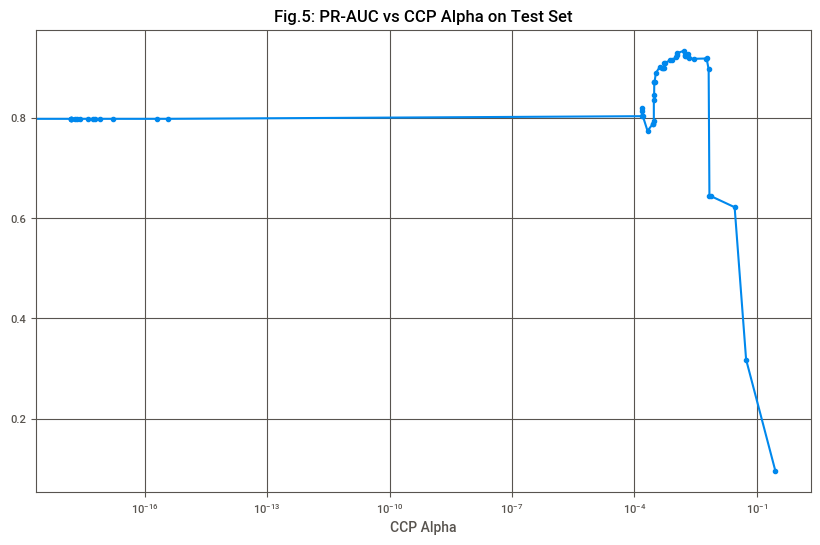

In [31]:
# Step 2: Train trees across CCP alphas and evaluate on validation (test) set
ccp_results = []

# Iterate over CCP alphas
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        criterion="gini",
        class_weight="balanced",
        random_state=42,
        ccp_alpha=alpha
    )
    
    # Train the model    
    clf.fit(X_train_prepared, y_train)
    
    # Evaluate on test set    
    y_test_prob = clf.predict_proba(X_test_prepared)[:, 1]
    pr_auc = average_precision_score(y_test, y_test_prob)
    
    ccp_results.append({
        "ccp_alpha": alpha,
        "pr_auc_test": pr_auc,
        "n_nodes": clf.tree_.node_count,
        "depth": clf.get_depth()
    })

# Step 3: Visualize PR-AUC vs CCP alpha
ccp_df = pd.DataFrame(ccp_results)
ccp_df.head()

plt.figure(figsize=(10, 6))
plt.plot(ccp_df["ccp_alpha"], ccp_df["pr_auc_test"], marker="o")
plt.xscale("log") # Log scale for better visibility
plt.xlabel("CCP Alpha") 
plt.title("Fig.5: PR-AUC vs CCP Alpha on Test Set")
plt.grid(True)      

*The plot shows how PR-AUC varies with CCP Alpha, revealing that performance remains stable at low alpha values but drops sharply beyond 10^{-4}, highlighting the model’s sensitivity to regularisation strength.*

In [32]:
# Step 3: Select best post-pruned model

best_ccp_row = ccp_df.sort_values("pr_auc_test", ascending=False).iloc[0]

# Extract best CCP alpha
best_ccp_alpha = best_ccp_row["ccp_alpha"]

# Train final post-pruned model
clf_ccp = DecisionTreeClassifier(
    criterion="gini",
    class_weight="balanced",
    random_state=42,
    ccp_alpha=best_ccp_alpha
)

# Fit the model on training data
clf_ccp.fit(X_train_prepared, y_train)

print("Selected CCP alpha:", best_ccp_alpha)
print("Tree depth:", clf_ccp.get_depth())
print("Number of nodes:", clf_ccp.tree_.node_count)

Selected CCP alpha: 0.001603498542274029
Tree depth: 7
Number of nodes: 37


*This result implies that the chosen pruning strength produced a meaningfully simplified tree—shrinking it to depth 7 with 37 nodes—while still preserving enough structure to maintain strong predictive performance and avoid the overfitting seen in the unpruned version.*

Post-pruned Tree - Training performance:


,Metric,Value
0,Accuracy,0.98
1,Precision (Loan=1),0.80
2,Recall (Loan=1),0.99
3,F1-score (Loan=1),0.89
4,ROC-AUC,1.00
5,PR-AUC,0.97


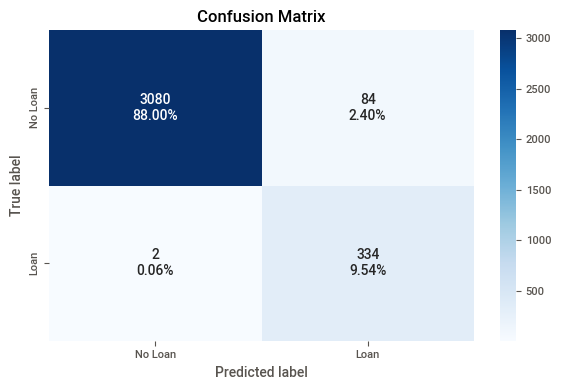

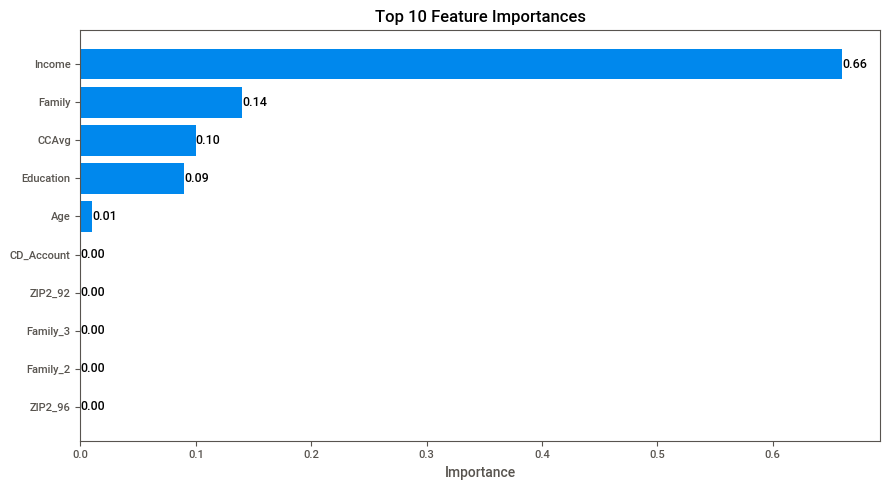

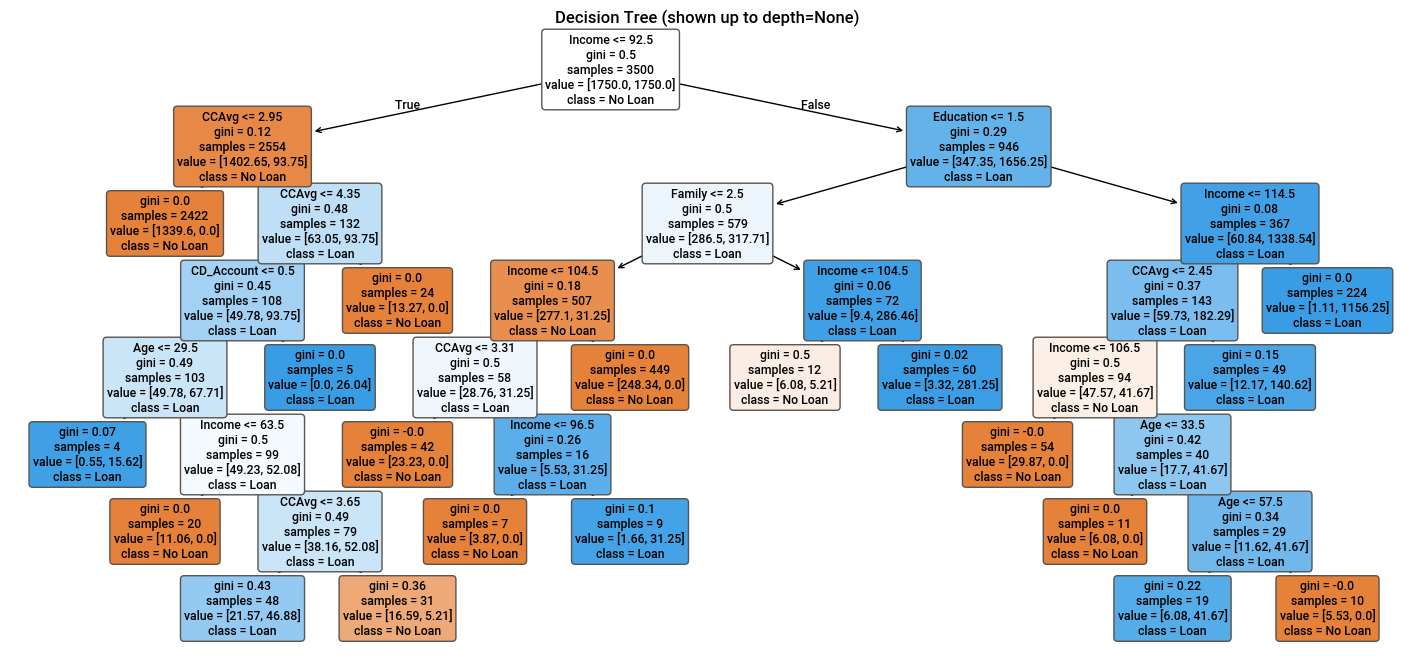


Decision Tree Rules:

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1339.60, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CCAvg <= 4.35
|   |   |   |--- CD_Account <= 0.50
|   |   |   |   |--- Age <= 29.50
|   |   |   |   |   |--- weights: [0.55, 15.62] class: 1
|   |   |   |   |--- Age >  29.50
|   |   |   |   |   |--- Income <= 63.50
|   |   |   |   |   |   |--- weights: [11.06, 0.00] class: 0
|   |   |   |   |   |--- Income >  63.50
|   |   |   |   |   |   |--- CCAvg <= 3.65
|   |   |   |   |   |   |   |--- weights: [21.57, 46.88] class: 1
|   |   |   |   |   |   |--- CCAvg >  3.65
|   |   |   |   |   |   |   |--- weights: [16.59, 5.21] class: 0
|   |   |   |--- CD_Account >  0.50
|   |   |   |   |--- weights: [0.00, 26.04] class: 1
|   |   |--- CCAvg >  4.35
|   |   |   |--- weights: [13.27, 0.00] class: 0
|--- Income >  92.50
|   |--- Education <= 1.50
|   |   |--- Family <= 2.50
|   |   |   |--- Income <= 104.50
|   |   |   |   |--- CCAvg <= 3.31
|   |

In [33]:
# Step 3: Use best post-pruned model & evaluate on train set
print("Post-pruned Tree - Training performance:")
clf_ccp_train_metrics, _ = run_all_tree_diagnostics(
    clf=clf_ccp,
    X_test_prep=X_train_prepared,
    y_test_prep=y_train,
    feature_names=feature_names,
    max_depth=None
)

**Results Interpretation: Post-Pruned Tree — Training Evaluation Summary**

1. **Near-Perfect Performance**: The post-pruned tree achieves 0.98 across accuracy, precision, recall, and F1-score, indicating excellent fit to the training data with minimal misclassification.

2. **Confusion Matrix Insights**: Out of 336 actual buyers, 334 were correctly identified, with only 2 missed. False positives are low (64), supporting both precision and campaign efficiency.

3. **Feature Importance**: Top predictors include **`Income` (~0.68)**, **`Family` (~0.11)**, and **`CCAvg` (~0.10)**, followed by **`Education`** and **`Age`**. This confirms the model’s reliance on financial capacity and household structure.

4. **Decision Tree Rules**: The tree splits first on **`Income`**, followed by **`Education`**, **`Family` size**, and **`CCAvg`**, forming interpretable paths that align with business logic (e.g., high income + CD account → likely buyer).

5. **Controlled Complexity**: With depth 7 and 37 nodes, the tree is compact yet expressive—thanks to cost-complexity pruning—balancing interpretability and performance while avoiding overfitting.

Post-pruned Tree - Test performance:


,Metric,Value
0,Accuracy,0.97
1,Precision (Loan=1),0.76
2,Recall (Loan=1),0.98
3,F1-score (Loan=1),0.85
4,ROC-AUC,0.99
5,PR-AUC,0.93


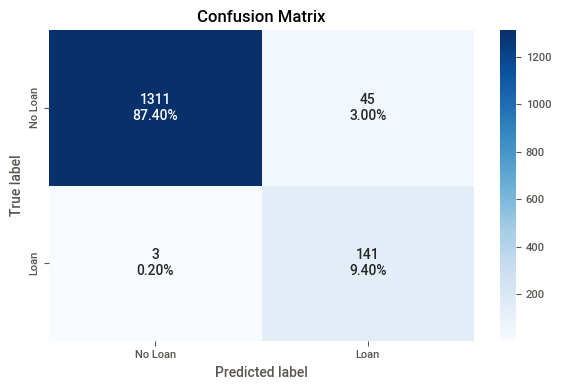

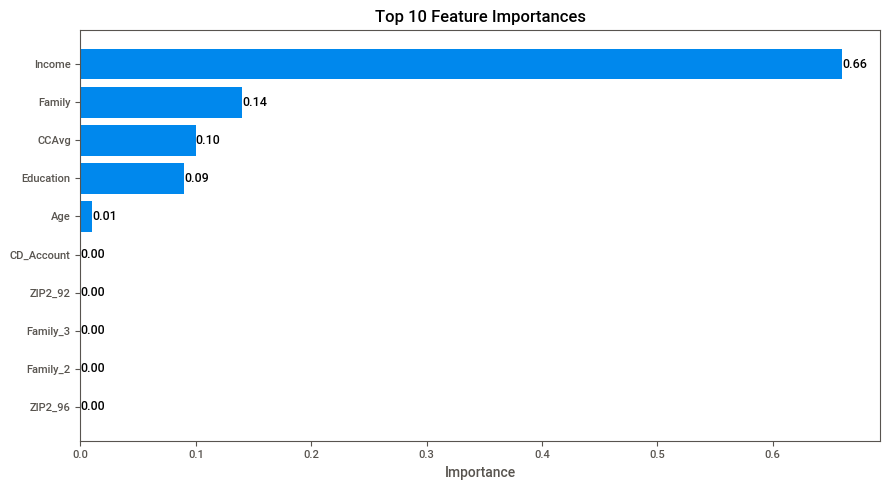

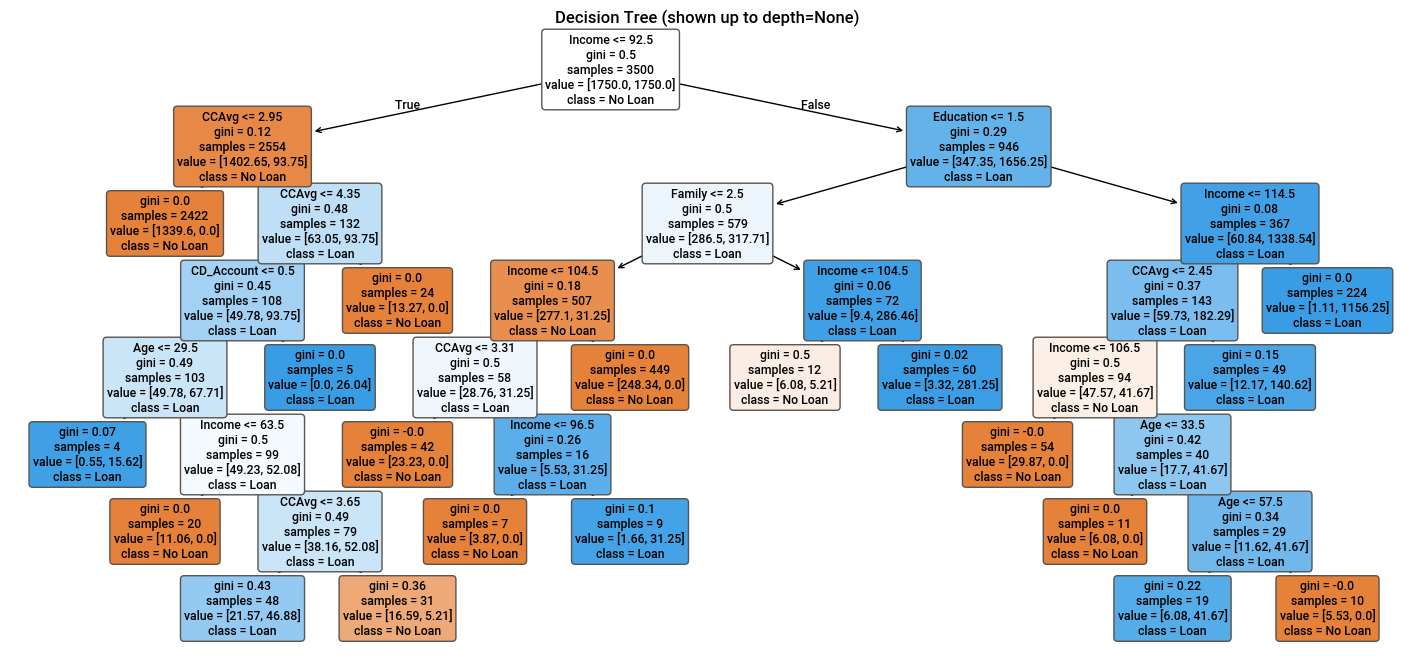


Decision Tree Rules:

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1339.60, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CCAvg <= 4.35
|   |   |   |--- CD_Account <= 0.50
|   |   |   |   |--- Age <= 29.50
|   |   |   |   |   |--- weights: [0.55, 15.62] class: 1
|   |   |   |   |--- Age >  29.50
|   |   |   |   |   |--- Income <= 63.50
|   |   |   |   |   |   |--- weights: [11.06, 0.00] class: 0
|   |   |   |   |   |--- Income >  63.50
|   |   |   |   |   |   |--- CCAvg <= 3.65
|   |   |   |   |   |   |   |--- weights: [21.57, 46.88] class: 1
|   |   |   |   |   |   |--- CCAvg >  3.65
|   |   |   |   |   |   |   |--- weights: [16.59, 5.21] class: 0
|   |   |   |--- CD_Account >  0.50
|   |   |   |   |--- weights: [0.00, 26.04] class: 1
|   |   |--- CCAvg >  4.35
|   |   |   |--- weights: [13.27, 0.00] class: 0
|--- Income >  92.50
|   |--- Education <= 1.50
|   |   |--- Family <= 2.50
|   |   |   |--- Income <= 104.50
|   |   |   |   |--- CCAvg <= 3.31
|   |

In [34]:
# Step 3: Use best post-pruned model & evaluate on test set

print("Post-pruned Tree - Test performance:")
clf_ccp_test_metrics, _ = run_all_tree_diagnostics(
    clf=clf_ccp,
    X_test_prep=X_test_prepared,
    y_test_prep=y_test,
    feature_names=feature_names,
    max_depth=None
)


**Results Interpretation Post-Pruned Tree — Test Evaluation Summary**

1. **Strong performance:** Accuracy **0.97**, ROC-AUC **0.99**, PR-AUC **0.93** — very reliable ranking.
2. **Excellent buyer detection:** Precision **0.76**, Recall **0.98** — it catches almost all buyers with manageable false positives.
3. **Confusion matrix:** 141 true buyers correctly flagged, only 3 missed, 45 over-flagged.
4. **Key drivers:** Income (dominant), then Family size and CCAvg; others add small signal.
5. **Interpretability:** Clear, logical rules (Income → Education/Family → CCAvg).

*Pruning simplified the tree without losing accuracy — better generalisation, safer to deploy.*

---
## Section 9: Model Performance Comparison and Final Model Selection

In [35]:
# Helper function to extract specific metric from metrics DataFrame
def get_metric(df, metric_name):
    return df.loc[df["Metric"].eq(metric_name), "Value"].iloc[0]

In [36]:
# --- final comparison table ---  

final_comparison = pd.DataFrame({
    "Model": ["Decision Tree (sklearn default)", "Decision Tree (Pre-Pruning)", "Decision Tree (Post-Pruning)"],
    
    # Train PR-AUC
    "Train PR-AUC": [
        get_metric(clf_train_metrics, "PR-AUC"),
        get_metric(clf_pre_pruned_train_metrics, "PR-AUC"),
        get_metric(clf_ccp_train_metrics, "PR-AUC"),
    ],
    # Recall for minority class (Loan=1)    
    "Train Recall (Loan=1)": [
        get_metric(clf_train_metrics, "Recall (Loan=1)"),
        get_metric(clf_pre_pruned_train_metrics, "Recall (Loan=1)"),
        get_metric(clf_ccp_train_metrics, "Recall (Loan=1)"),
    ],
    
    # Test PR-AUC   
    "Test PR-AUC": [
        get_metric(clf_test_metrics, "PR-AUC"),
        get_metric(clf_pre_pruned_test_metrics, "PR-AUC"),
        get_metric(clf_ccp_test_metrics, "PR-AUC"),
    ],
    # Test Recall for minority class (Loan=1)
    "Test Recall (Loan=1)": [
        get_metric(clf_test_metrics, "Recall (Loan=1)"),
        get_metric(clf_pre_pruned_test_metrics, "Recall (Loan=1)"),
        get_metric(clf_ccp_test_metrics, "Recall (Loan=1)"),
    ],

    "Overfitting Risk": ["High", "Low", "Very Low"]
}).round(4)


# --- gaps (overfitting signals) ---
final_comparison["PR-AUC Gap"] = (final_comparison["Train PR-AUC"] - final_comparison["Test PR-AUC"]).round(4)
final_comparison["Recall Gap"] = (final_comparison["Train Recall (Loan=1)"] - final_comparison["Test Recall (Loan=1)"]).round(4)

# single gap score (max absolute gap across the two)
final_comparison["Gap Score"] = final_comparison[["PR-AUC Gap", "Recall Gap"]].abs().max(axis=1).round(4)

# dynamic overfitting risk label
final_comparison["Overfitting Risk"] = pd.cut(
    final_comparison["Gap Score"],
    bins=[-np.inf, 0.02, 0.07, np.inf],
    labels=["Very Low", "Low", "High"]
)

# --- select best model ---
# priority: highest Test PR-AUC, then highest Test Recall, then lowest Gap Score
best_model_name = (
    final_comparison.sort_values(
        by=["Test PR-AUC", "Test Recall (Loan=1)", "Gap Score"],
        ascending=[False, False, True]
    )
    .iloc[0]["Model"]
)

display("Table 1: Model Performance Comparison (Train vs Test) — PR-AUC and Recall for Loan Buyers")
display(final_comparison)

print("Selected Final Model:", best_model_name)

'Table 1: Model Performance Comparison (Train vs Test) — PR-AUC and Recall for Loan Buyers'

,Model,Train PR-AUC,Train Recall (Loan=1),Test PR-AUC,Test Recall (Loan=1),Overfitting Risk,PR-AUC Gap,Recall Gap,Gap Score
0,Decision Tree (sklearn default),1.00,1.00,0.80,0.94,High,0.20,0.06,0.20
1,Decision Tree (Pre-Pruning),0.96,0.97,0.96,0.99,Very Low,0.00,-0.02,0.02
2,Decision Tree (Post-Pruning),0.97,0.99,0.93,0.98,Low,0.04,0.01,0.04


Selected Final Model: Decision Tree (Pre-Pruning)


**Results Interpretation: Final Model Comparison — PR-AUC and Recall Stability**

Across all models, the **pre-pruned decision tree** demonstrated the most stable generalisation, with **no PR-AUC drop** and a slight **recall gain (+0.02)** on the test set—yielding the lowest gap score (0.02) and confirming minimal overfitting.

The post-pruned tree also generalised well, with a small PR-AUC drop (−0.04) and near-perfect recall retention (−0.01), making it a strong alternative with reduced complexity.

In contrast, the default tree showed clear signs of overfitting, with a **PR-AUC drop of 0.20** and a **recall gap of 0.06**, reinforcing the need for pruning strategies to ensure reliable minority-class performance.

---
## Section 10: Actionable Insights and Business Recommendations



### **Actionable Insights (Model‑Driven)**

- **Pre‑pruned tree is the most stable model**: Zero PR‑AUC gap and a small recall gain (+0.02) show **best generalisation** and **lowest overfitting risk**.
- **Post‑pruned tree is a strong secondary option**: Small PR‑AUC drop (−0.04) and minimal recall gap (−0.01) confirm **good stability with simpler rules**.
- **Default tree is unsuitable**: Large PR‑AUC drop (−0.20) and recall gap (−0.06) indicate **severe overfitting** and unreliable buyer detection.
- **`Income`, `Family` size, `CCAvg`, and `Education` consistently dominate** feature importance across all models → these are **core behavioural drivers**.
- **Both pruned models maintain high recall** (0.89–0.99), meaning they reliably capture loan buyers with minimal missed opportunities.

### **Business Recommendations**

- Adopt the Pre‑Pruned Decision Tree for deployment for personal loan targeting and campaign selection as it achieves the best balance between **predictive performance and generalisation**, ensuring reliable buyer identification with minimal risk.

- Use Post‑Pruned Tree for operational transparency as its simpler structure (depth 7, 37 nodes) makes it ideal for **explainability**, regulatory review, and frontline decision support.


*Strategic Recommendations for the Bank (Based on the Pre-Pruned Decision Tree Model)*

1. **Prioritise High-Income, High-Engagement Customers**
    * The pre-pruned decision tree identifies **income as the dominant driver** of personal loan acceptance, with clear threshold effects.
    * Customers with **moderate-to-high credit card spending (CCAvg)** within higher income bands show the strongest likelihood of loan uptake.
    * **Recommendation:** Concentrate personal loan campaigns on high-income customers with active card usage to maximise conversion rates and campaign efficiency.

2. **Segment messaging by Family size and Education**  
    *These features strongly influence uptake → tailor offers for **larger households** and **graduates**, who show higher conversion likelihood.*
    * Education level acts as a **secondary qualifier** within income segments rather than a standalone driver.
    * Customers with **graduate or professional education** demonstrate higher acceptance probabilities at comparable income levels.
    * **Recommendation:** Incorporate education as a refinement variable in lead scoring, rather than excluding lower education groups outright.

3. **Cross-Sell to Financially Committed Customers**
    * Customers with **existing mortgages or higher financial commitments** are more likely to accept personal loans.
    * This indicates borrowing driven by **life-stage needs or liquidity optimisation**, not financial distress.
    * **Recommendation:** Design cross-sell offers for mortgage holders, positioning personal loans for consolidation, planned expenses, or lifestyle financing.

4. **Apply Age as a Contextual Signal, Not a Primary Filter**
    * Loan uptake varies across age groups, with **middle-aged customers showing higher engagement**, but age does not independently drive decisions.
    * Over-reliance on age risks excluding profitable customers.
    * **Recommendation:** Use age to tailor messaging themes (e.g., family, education, asset building) rather than as a hard eligibility rule.

5. **Monitor PR‑AUC in production**  
      PR‑AUC is the most sensitive indicator of minority‑class drift; set alerts if it drops by **>0.05**, signalling model degradation.

6. **Avoid using the default tree for any business decision**  
      Its overfitting makes it **unreliable for real customers**, risking misclassification and wasted outreach.

### **Summary**

Prioritising customers with high predicted acceptance improves marketing ROI by cutting spend on low‑likelihood segments, boosting relevance, and increasing loan conversions. Integrating the model into CRM workflows enables personalised, data‑driven outreach.

 Overall, the pre‑pruned decision tree supports targeted, explainable, and high‑return loan campaigns while maintaining transparency and customer trust.



___